Step 1: Download the dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'berkeley-segmentation-dataset-500-bsds500' dataset.
Path to dataset files: /kaggle/input/berkeley-segmentation-dataset-500-bsds500


In [ ]:
import os
import shutil

src = "/root/.cache/kagglehub/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/versions/1"

dst = "/content/drive/MyDrive/Mask-Generation"

os.makedirs(dst, exist_ok=True)

print("Source:", src)
print("Destination:", dst)

Source: /root/.cache/kagglehub/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/versions/1
Destination: /content/drive/MyDrive/Mask-Generation


In [ ]:
shutil.copytree(src, dst, dirs_exist_ok=True)

print("Copy finished")

Copy finished


Step 2: Import libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import sobel

Step 3: Find one image from the dataset

In [ ]:
import os

base = "/content/drive/MyDrive/Mask-Generation"

print("Exists:", os.path.exists(base))
print("Contents:")
print(os.listdir(base))

Exists: True
Contents:
['images', 'ground_truth', 'generated_masks']


In [ ]:
import os

image_root = "/content/drive/MyDrive/Mask-Generation/images/train"
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))


print("Number of images:", len(image_list))
if len(image_list) > 0:
    print("First image path:", image_list[0])
else:
    print("No images found. Check the folder path again.")

Number of images: 200
First image path: /content/drive/MyDrive/Mask-Generation/images/train/61060.jpg


Step 4: Load the image and convert it to grayscale

Image shape: (321, 481)


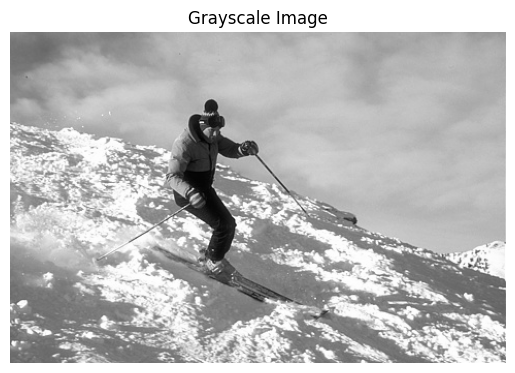

In [ ]:
img = Image.open(image_list[0]).convert("L")
img_array = np.array(img)

print("Image shape:", img_array.shape)

plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Step 5: Create a mask using thresholding

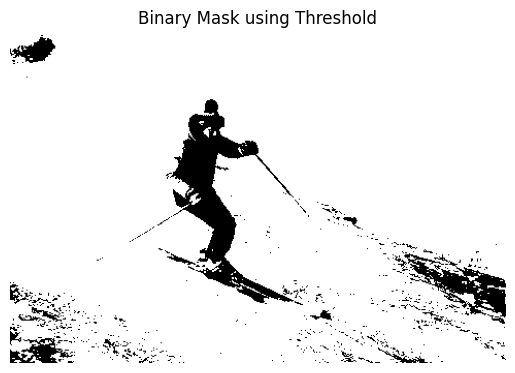

In [ ]:
T = 120   # threshold value

mask = (img_array > T).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Binary Mask using Threshold")
plt.axis("off")
plt.show()

Step 6: Detect edges using gradients

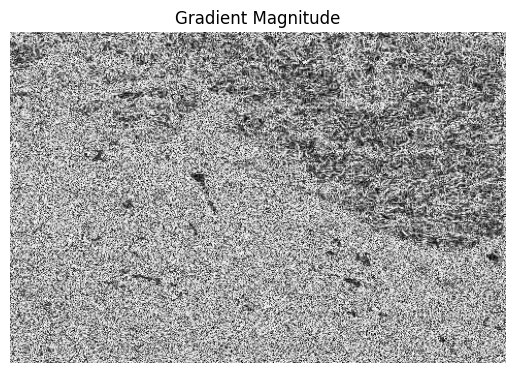

In [ ]:
Gx = sobel(img_array, axis=1)   # horizontal gradient
Gy = sobel(img_array, axis=0)   # vertical gradient

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

Step 7: Create edge image by thresholding gradient magnitude

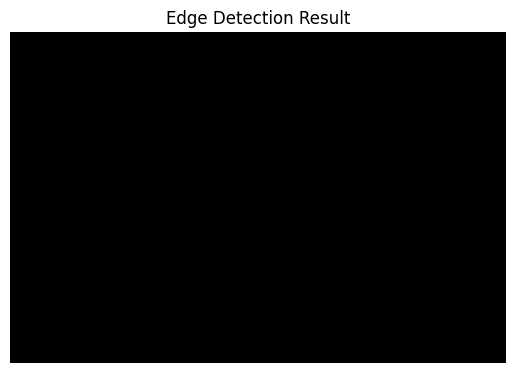

In [ ]:
Te = 80   # edge threshold

edges = (gradient_magnitude > Te).astype(np.uint8)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection Result")
plt.axis("off")
plt.show()

Step 8: Show all results together

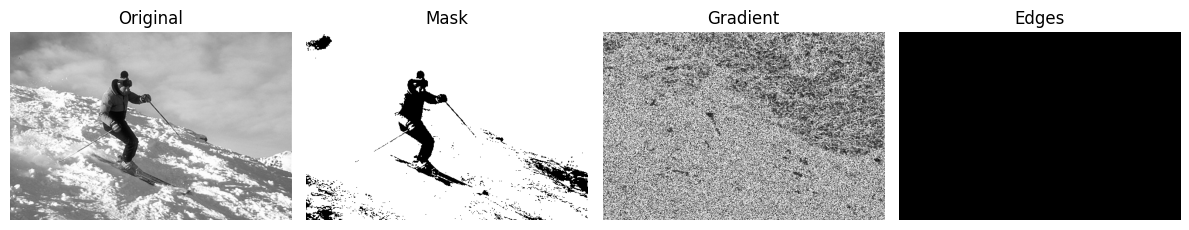

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

#Whole Dataset

9) Collect all images in the dataset

In [ ]:
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))

image_list = sorted(image_list)

print("Total images found:", len(image_list))
print("Example:", image_list[0])




Total images found: 200
Example: /content/drive/MyDrive/Mask-Generation/images/train/100075.jpg


10) Create a folder to save masks

In [ ]:
mask_folder = os.path.join(image_root, "generated_masks_New")
os.makedirs(mask_folder, exist_ok=True)

print("Masks will be saved in:", mask_folder)

Masks will be saved in: /content/drive/MyDrive/Mask-Generation/images/train/generated_masks_New


11) Set one threshold value for the whole dataset

In [ ]:
T = 120
print("Using threshold:", T)

Using threshold: 120


12) Generate masks for all images

In [ ]:
for img_path in image_list:
    # Load image and convert to grayscale
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    # Threshold-based mask generation
    mask = (img_array > T).astype(np.uint8) * 255

    # Create output file name
    img_name = os.path.basename(img_path)
    name_without_ext = os.path.splitext(img_name)[0]
    save_path = os.path.join(mask_folder, name_without_ext + "_mask.png")

    # Save mask
    Image.fromarray(mask).save(save_path)

print("All masks generated successfully.")

All masks generated successfully.


13) Show one original image and its mask

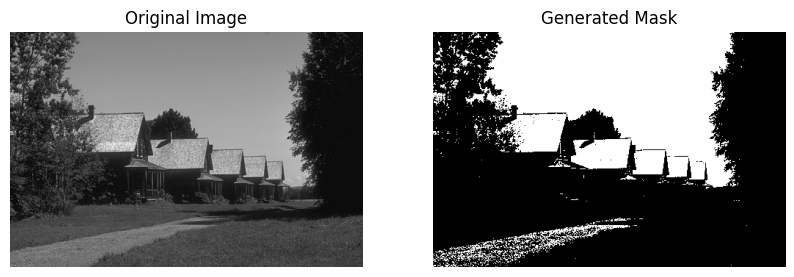

In [ ]:
sample_img_path = image_list[100]

img = Image.open(sample_img_path).convert("L")
img_array = np.array(img)

mask_path = os.path.join(
    mask_folder,
    os.path.splitext(os.path.basename(sample_img_path))[0] + "_mask.png"
)
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")

plt.show()